## Exercise 17.3 (Jupyter plotting)
Plot the function f(x) = 100·(x - 3)2 + ex for the x in ther range [0, 10] using matplotlib.pyplot in Jupyter.

## Exercise 17.4 (Jupyter function minimization)
Find the minimum of the function in Exercise 17.3 using scipy.optimize.minimize. Extend the plot in Exercise 17.3 to illustrate the minimum, e.g. using a dot.

2.9083658674010855


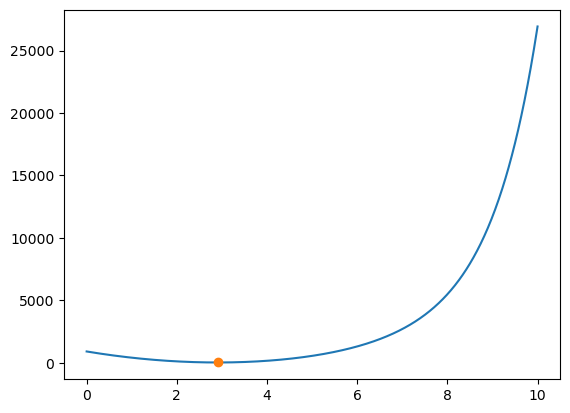

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

x = np.linspace(0, 10, 1000)

def f(x): 
    return 100*(x-3)**2+np.exp(x)

plt.plot(x, f(x))

m = minimize(f, [4])
print(m.x[0])
plt.plot(m.x[0], f(m.x[0]), "o")
plt.show()

## Exercise 18.1 (numpy)
Generate two 5x5 matrices with entries drawn from a standard normal distribution (mean 0, variance 1). numpy.random.normal might come in handy here. Find the inverse of the matrices. Check by matrix multiplication, that it is in fact the inverses you have found.

Find the mean of each row and each column of the matrices without using loops. numpy.mean might come in handy here.

Create a 100x100 matrix with entries drawn from the uniform distribution between 0 and 1. Find all rows where the sum exceeds 55. Find both the row index and the sum. (Try to have a look at the functions numpy.sum and numpy.where).

In [74]:
mat = np.array([np.random.normal() for i in range (5*5)]).reshape(5,5)
matI = np.linalg.inv(mat)
print(np.round(mat @ matI))

print(np.mean(mat, (0))) # Columns
print(np.mean(mat, (1))) # Rows

m = np.array([np.random.uniform() for i in range (100*100)]).reshape(100,100)
s = np.sum(m, axis=(1))
w = np.where(s > 55)
print(w[0])
print(np.sum(m[:][w], axis=(1)))

[[ 1. -0.  0.  0. -0.]
 [-0.  1. -0.  0. -0.]
 [-0. -0.  1. -0. -0.]
 [-0.  0.  0.  1.  0.]
 [ 0.  0.  0.  0.  1.]]
[-1.0045104   0.54923609  0.03188465 -0.18277057 -0.05625753]
[-0.43982791 -0.23940054  0.38780544  0.11408445 -0.4850792 ]
[19 29 50 95]
[59.87222796 55.174929   56.46963033 56.41685042]


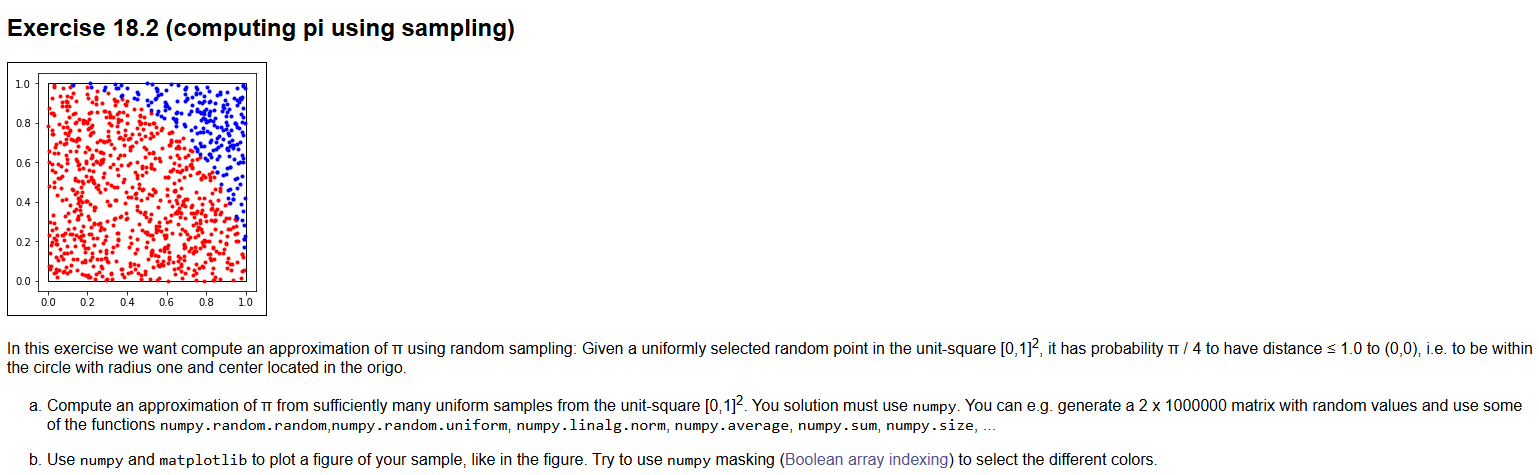

3.13452


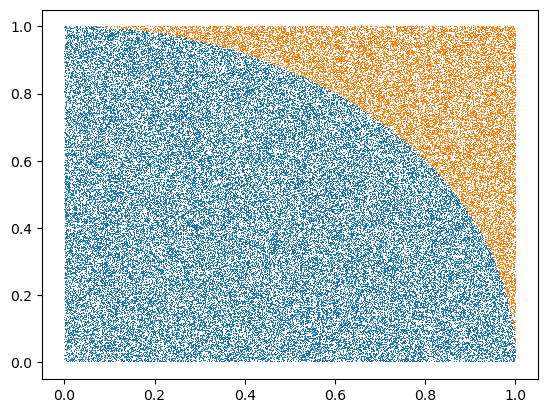

In [99]:
points = np.array([(np.random.uniform(), np.random.uniform()) for _ in range(100000)])
circle = points[np.sqrt(points[:, 0]**2 + points[:, 1]**2) < 1]
noncirc = points[np.sqrt(points[:, 0]**2 + points[:, 1]**2) > 1]

print(4*len(circle)/len(points))

c1, c2 = zip(*circle)
plt.plot(c1,c2,",")
x, y = zip(*noncirc)
plt.plot(x,y, ",")

## Exercise 18.3 (polynomial fit)
Consider the below list L of 2D points. Apply numpy.polyfit for different degrees of the polynomial fitting, and find the minimum degree polynomial where the maximal vertical distance between a point (x, y) in L and the polynomial poly is at most 1, i.e. abs(y - poly(x)) <= 1 for all (x, y) in L. Plot the data points and the different polynomial approximations. Present your work in Jupyter.

L = [(2, 3), (5, 7), (4, 10), (10, 15), (2.5, 5), (8, 4), (9, 10), (6, 6)]

8


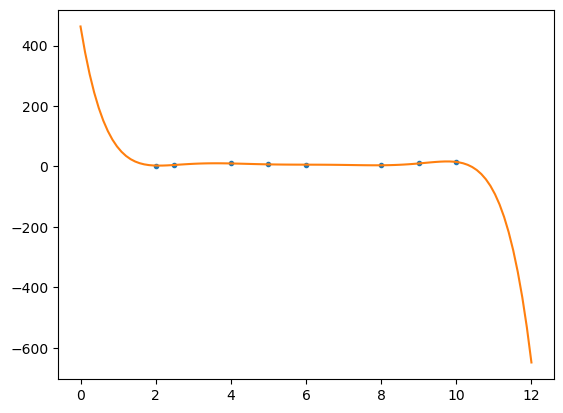

In [124]:
L = np.array([(2, 3), (5, 7), (4, 10), (10, 15), (2.5, 5), (8, 4), (9, 10), (6, 6)])
i = 0
x, y = zip(*L)

fy = np.zeros_like(y)

while not all(np.abs(y - fy) <= 1): 
    args = np.polyfit(x, y, i)
    fy = np.polyval(args, x)
    i += 1

print(i)
plt.plot(x,y,".")
xl = np.linspace(0, 12, 100)
plt.plot(xl, np.polyval(args, xl))